
==================== STARTING ANALYSIS: QB ====================

[EDA] Data Normalization Results for QB:
Example: Transformation for Josh Allen
                       Raw (Season Total)  Processed (Per-Game)
completions                           152             11.692308
attempts                              270             20.769231
passing_yards                        1812            139.384615
passing_tds                            16              1.230769
passing_interceptions                   6              0.461538
rushing_yards                         204             15.692308
rushing_tds                             5              0.384615

--- Best Historical Comparisons for QB ---
College: Josh Allen | Pro Counterpart: Lamar Jackson | Similarity: 0.93
College: Lamar Jackson | Pro Counterpart: Josh Allen | Similarity: 0.57
College: Kyler Murray | Pro Counterpart: Josh Allen | Similarity: 0.07
College: Baker Mayfield | Pro Counterpart: Patrick Mahomes | Similarity: 0.12
Colle

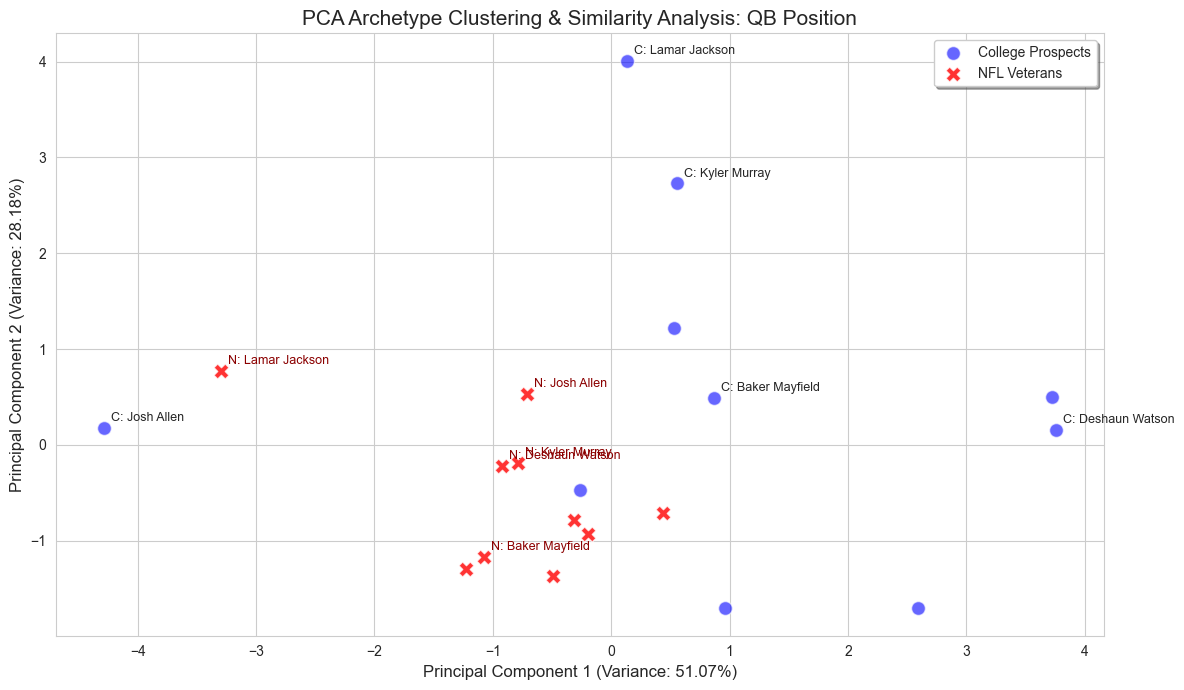


==================== STARTING ANALYSIS: RB ====================

[EDA] Data Normalization Results for RB:
Example: Transformation for Josh Jacobs
                 Raw (Season Total)  Processed (Per-Game)
carries                         120              9.230769
rushing_yards                   640             49.230769
rushing_tds                      11              0.846154
receptions                       20              1.538462
receiving_yards                 247             19.000000
receiving_tds                     3              0.230769

--- Best Historical Comparisons for RB ---
College: Josh Jacobs | Pro Counterpart: James Conner | Similarity: 0.39
College: Aaron Jones | Pro Counterpart: Derrick Henry | Similarity: 0.15
College: Alvin Kamara | Pro Counterpart: Alvin Kamara | Similarity: 0.59
College: Derrick Henry | Pro Counterpart: Derrick Henry | Similarity: 0.60
College: Nick Chubb | Pro Counterpart: Derrick Henry | Similarity: 0.93
College: Tony Pollard | Pro Counterpar

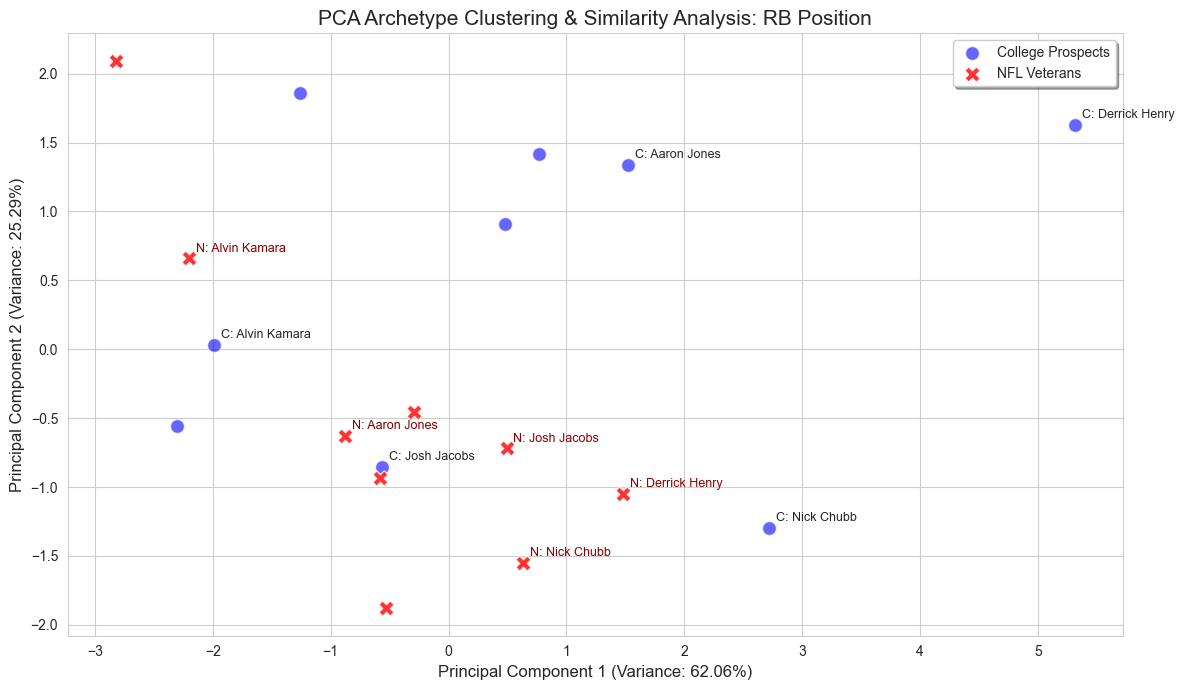


==================== STARTING ANALYSIS: WR ====================

[EDA] Data Normalization Results for WR:
Example: Transformation for Stefon Diggs
                 Raw (Season Total)  Processed (Per-Game)
receptions                       62              4.769231
receiving_yards                 792             60.923077
receiving_tds                     5              0.384615

--- Best Historical Comparisons for WR ---
College: Stefon Diggs | Pro Counterpart: Amari Cooper | Similarity: 0.99
College: Mike Evans | Pro Counterpart: Justin Jefferson | Similarity: 0.01
College: Amari Cooper | Pro Counterpart: Justin Jefferson | Similarity: 0.28
College: D.K. Metcalf | Pro Counterpart: Mike Evans | Similarity: 0.99
College: A.J. Brown | Pro Counterpart: Justin Jefferson | Similarity: 0.91
College: Justin Jefferson | Pro Counterpart: Justin Jefferson | Similarity: 0.04
College: Jaylen Waddle | Pro Counterpart: Mike Evans | Similarity: 1.00
College: DeAndre Hopkins | Pro Counterpart: Justin J

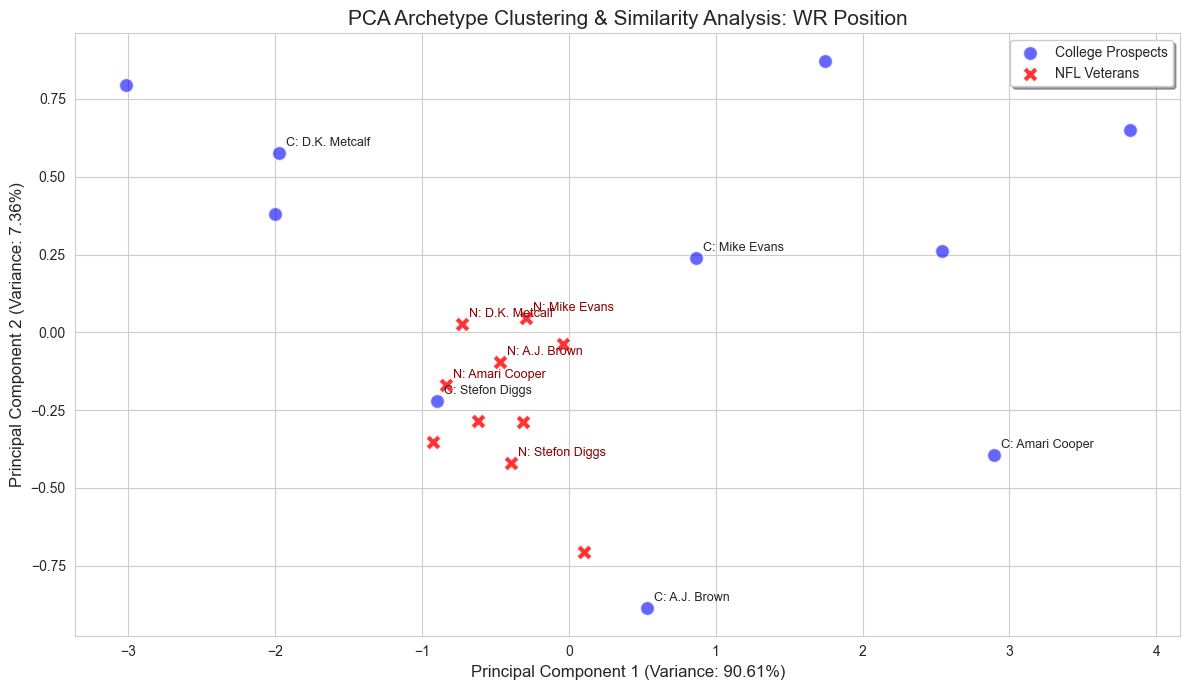


==================== STARTING ANALYSIS: CB ====================

[EDA] Data Normalization Results for CB:
Example: Transformation for Patrick Surtain II
                      Raw (Season Total)  Processed (Per-Game)
def_pass_defended                   11.0              0.846154
def_interceptions                    1.0              0.076923
def_tackles_solo                    20.0              1.538462
def_sacks                            0.0              0.000000
def_tds                              1.0              0.076923
def_tackles_for_loss                 3.5              0.269231

--- Best Historical Comparisons for CB ---
College: Patrick Surtain II | Pro Counterpart: Carlton Davis | Similarity: -0.23
College: Marlon Humphrey | Pro Counterpart: Patrick Surtain II | Similarity: 0.02
College: Denzel Ward | Pro Counterpart: Denzel Ward | Similarity: 0.71
College: Carlton Davis | Pro Counterpart: Patrick Surtain II | Similarity: 0.41
College: Tre'Davious White | Pro Counterpart: M

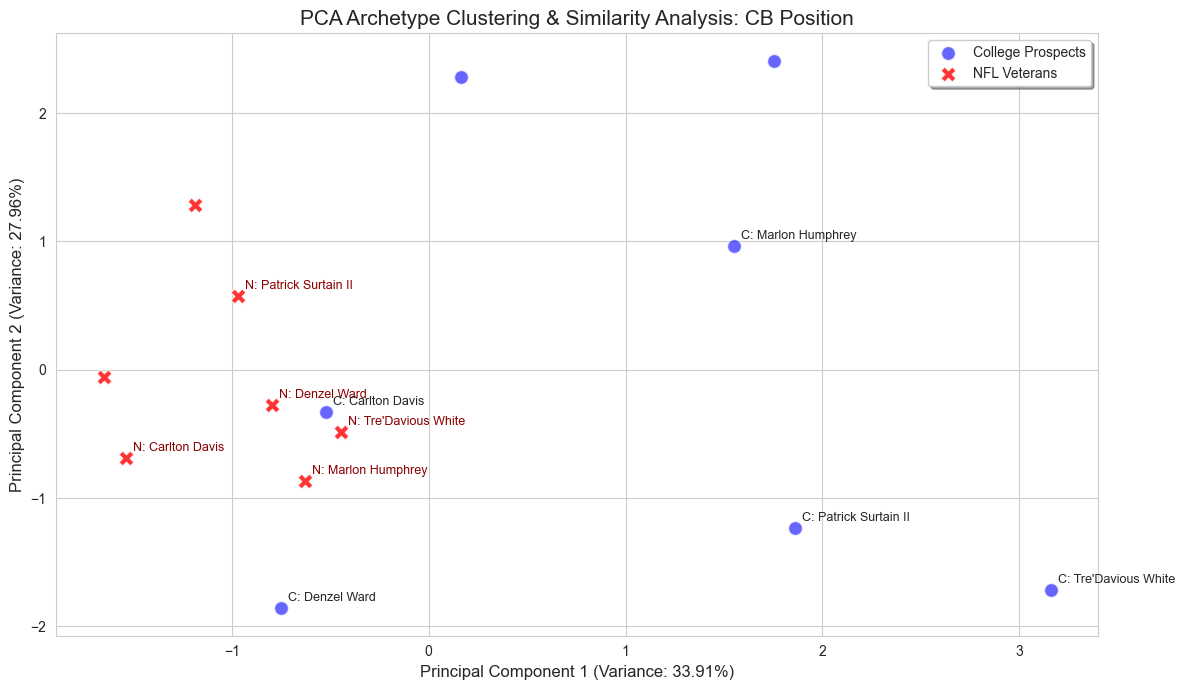


==================== STARTING ANALYSIS: LB ====================

[EDA] Data Normalization Results for LB:
Example: Transformation for Devin White
                      Raw (Season Total)  Processed (Per-Game)
def_tackles_solo                    62.0              4.769231
def_tackles_for_loss                12.0              0.923077
def_sacks                            3.0              0.230769
def_pass_defended                    6.0              0.461538
def_tds                              0.0              0.000000

--- Best Historical Comparisons for LB ---
College: Devin White | Pro Counterpart: Tremaine Edmunds | Similarity: 0.50
College: Zach Cunningham | Pro Counterpart: Roquan Smith | Similarity: 0.22
College: Fred Warner | Pro Counterpart: Tremaine Edmunds | Similarity: 0.77
College: Tremaine Edmunds | Pro Counterpart: Micah Parsons | Similarity: 0.29
College: T.J. Watt | Pro Counterpart: T.J. Watt | Similarity: 0.37
College: Jordyn Brooks | Pro Counterpart: Micah Parsons | 

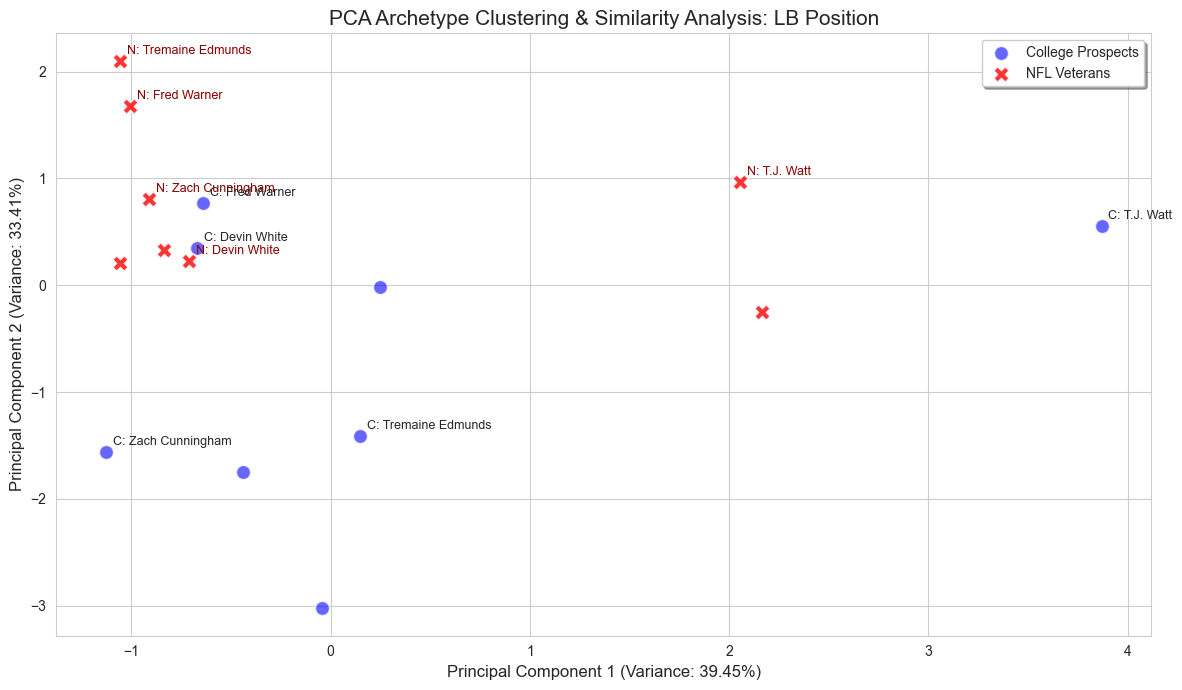

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 1. CONFIGURATION & FEATURE MAPPING
# ==========================================

CONFIG = {
    'QB': {
        'map': {'passing_COMPLETIONS': 'completions', 'passing_ATT': 'attempts', 'passing_YDS': 'passing_yards', 
                'passing_TD': 'passing_tds', 'passing_INT': 'passing_interceptions', 'rushing_YDS': 'rushing_yards', 'rushing_TD': 'rushing_tds'},
        'unified': ['completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'rushing_yards', 'rushing_tds']
    },
    'RB': {
        'map': {'rushing_CAR': 'carries', 'rushing_YDS': 'rushing_yards', 'rushing_TD': 'rushing_tds', 
                'receiving_REC': 'receptions', 'receiving_YDS': 'receiving_yards', 'receiving_TD': 'receiving_tds'},
        'unified': ['carries', 'rushing_yards', 'rushing_tds', 'receptions', 'receiving_yards', 'receiving_tds']
    },
    'WR': {
        'map': {'receiving_REC': 'receptions', 'receiving_YDS': 'receiving_yards', 'receiving_TD': 'receiving_tds'},
        'unified': ['receptions', 'receiving_yards', 'receiving_tds']
    },
    'CB': {
        'map': {'defensive_PD': 'def_pass_defended', 'interceptions_INT': 'def_interceptions', 'defensive_SOLO': 'def_tackles_solo', 
                'defensive_SACKS': 'def_sacks', 'defensive_TD': 'def_tds', 'defensive_TFL': 'def_tackles_for_loss'},
        'unified': ['def_pass_defended', 'def_interceptions', 'def_tackles_solo', 'def_sacks', 'def_tds', 'def_tackles_for_loss']
    },
    'LB': {
        'map': {'defensive_SOLO': 'def_tackles_solo', 'defensive_TFL': 'def_tackles_for_loss', 'defensive_SACKS': 'def_sacks', 
                'defensive_PD': 'def_pass_defended', 'defensive_TD': 'def_tds'},
        'unified': ['def_tackles_solo', 'def_tackles_for_loss', 'def_sacks', 'def_pass_defended', 'def_tds']
    }
}

def process_position(pos):
    print(f"\n{'='*20} STARTING ANALYSIS: {pos} {'='*20}")
    
    mapping = CONFIG[pos]['map']
    unified_features = CONFIG[pos]['unified']
    
    college_raw_list = []
    college_processed_list = []
    nfl_list = []
    player_names = []

    college_dir = f"data/college/{pos}"
    nfl_dir = f"data/nfl/{pos}"

    for file in os.listdir(college_dir):
        if file.endswith(".csv"):

            c_path, n_path = os.path.join(college_dir, file), os.path.join(nfl_dir, file)
            if not os.path.exists(n_path): continue

            c_df = pd.read_csv(c_path).rename(columns=mapping).rename(columns={'player': 'player_name'})
            n_df = pd.read_csv(n_path).rename(columns={'player_display_name': 'player_name'})

            if all(f in c_df.columns for f in unified_features) and all(f in n_df.columns for f in unified_features):
                college_raw_list.append(c_df[unified_features].iloc[0].copy())
    
                college_row = c_df[unified_features].iloc[0].copy() / 13.0
                college_processed_list.append(college_row)
                
                nfl_list.append(n_df[unified_features].iloc[0])
                player_names.append(c_df['player_name'].iloc[0])

    if not college_processed_list: return

    df_raw = pd.DataFrame(college_raw_list, index=player_names)
    df_college = pd.DataFrame(college_processed_list, index=player_names)
    df_nfl = pd.DataFrame(nfl_list, index=player_names)

    # ==========================================
    # 2. EXPLORATORY DATA ANALYSIS (EDA)
    # ==========================================
    print(f"\n[EDA] Data Normalization Results for {pos}:")
    display_df = pd.DataFrame({'Raw (Season Total)': df_raw.iloc[0], 'Processed (Per-Game)': df_college.iloc[0]})

    print(f"Example: Transformation for {player_names[0]}")
    print(display_df)

    # ==========================================
    # 3. ALGORITHMIC ANALYSIS (PCA, GMM, & SIMILARITY)
    # ==========================================
    scaler = StandardScaler()
    full_scaled = scaler.fit_transform(pd.concat([df_college, df_nfl]))
    c_scaled, n_scaled = full_scaled[:len(df_college)], full_scaled[len(df_college):]

    sim_matrix = cosine_similarity(c_scaled, n_scaled)
    gmm = GaussianMixture(n_components=3, random_state=42)
    clusters = gmm.fit_predict(full_scaled)
    
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(full_scaled)

    # ==========================================
    # 4. FINAL VISUALIZATIONS & RESULTS
    # ==========================================
    print(f"\n--- Best Historical Comparisons for {pos} ---")
    for i, name in enumerate(player_names):
        match_idx = np.argmax(sim_matrix[i])
        print(f"College: {name} | Pro Counterpart: {player_names[match_idx]} | Similarity: {sim_matrix[i][match_idx]:.2f}")

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    plt.scatter(pca_res[:len(df_college), 0], pca_res[:len(df_college), 1], label='College Prospects', c='blue', edgecolors='white', s=100, alpha=0.6)
    plt.scatter(pca_res[len(df_college):, 0], pca_res[len(df_college):, 1], label='NFL Veterans', marker='X', c='red', edgecolors='white', s=120, alpha=0.8)
    
    for i, name in enumerate(player_names):
        if i < 5:
            plt.annotate(f"C: {name}", (pca_res[i, 0], pca_res[i, 1]), fontsize=9, xytext=(5,5), textcoords='offset points')
            plt.annotate(f"N: {name}", (pca_res[i+len(df_college), 0], pca_res[i+len(df_college), 1]), fontsize=9, color='darkred', xytext=(5,5), textcoords='offset points')

    plt.title(f"PCA Archetype Clustering & Similarity Analysis: {pos} Position", fontsize=15)
    plt.xlabel(f"Principal Component 1 (Variance: {pca.explained_variance_ratio_[0]:.2%})", fontsize=12)
    plt.ylabel(f"Principal Component 2 (Variance: {pca.explained_variance_ratio_[1]:.2%})", fontsize=12)

    plt.legend(frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

for position in ['QB', 'RB', 'WR', 'CB', 'LB']:
    process_position(position)